In [2]:
import glob
import re
from collections import defaultdict
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.parent.parent # probably could do a config instead...
sys.path.insert(0, str(PROJECT_ROOT))

from analysis.result_loading import load_and_combine_vw_models
from configuration.configurable_factory import resolve_configurable_factories
from envs.gym_make import get_acrobot_env_config
from experiments.paths import RESULTS_DIR

## Evaluating Acrobot Results for Different VW Implementations

This notebook aims to compare the quality of computation between pyro-based VW, numpyro-jax-based VW, and np-jax VW using Blackjax samplers.

We take the pyro-based VW as the ground-truth implementation, and compare the other two to it as a baseline. We are interested in 2 main questions:
- Do we recover the same-ish posterior/performance?
- How much faster are we?

We therefore assume that pyro-based VW works as best as possible in the sense of recovering the posterior, and we are mostly interested whether we can do the same but faster with the other two implementations.

To run this analysis, you must first run the loop for each of the models. **TODO: Prepare a bash script to run to get all necessary results**.

In [4]:
def gym_test(reward_model, env_name, num_actions, test_evals=300, aggregation_fn=lambda x: torch.median(x, dim=-1)[0]):
    results = []
    env = gym.make(env_name)
    for t in tqdm(range(test_evals), desc="Testing"):
        observation, info = env.reset()
        done = truncated = False
        rewards = []
        while not (done or truncated):
            logit = aggregation_fn(reward_model.q_samples(torch.from_numpy(observation).float().unsqueeze(0), torch.eye(num_actions, dtype=torch.float)))
            # logit = torch.randn_like(logit)
            action = torch.argmax(logit, dim=1)
            observation, reward, done, truncated, info = env.step(int(action))
            rewards.append(reward)

        results.append(sum(rewards))
    env.close()
    mean_res = sum(results) / test_evals
    print(f"Mean Reward: {mean_res}")
    
    plt.hist(results, bins=10)

    return results

def gym_test_random_policy(env_name, test_evals=1000):
    results = []
    env = gym.make(env_name)
    for t in tqdm(range(test_evals), desc="Testing"):
        observation, info = env.reset()
        done = truncated = False
        rewards = []
        while not (done or truncated):
            # logit = torch.randn_like(logit)
            action = np.random.randint(0, env_config.a_dim)
            observation, reward, done, truncated, info = env.step(int(action))
            rewards.append(reward)

        results.append(sum(rewards))
    env.close()
    mean_res = sum(results) / test_evals
    print(f"Mean Reward: {mean_res}")
    
    plt.hist(results, bins=10)

    return results

def build_model_result_files(model: str) -> dict:
    '''
    Model options: 'original', 'numpyro__','numpyro_blackjax'
    '''
    all_model_results = [file_name for file_name in glob.glob(str(RESULTS_DIR / f"birl/*_{model}*.pt"))
               if "_10s_" not in file_name and 
               "info" not in file_name and
               ".checkpoint." not in file_name and 
               "evaluation" not in file_name]
    
    model_result_files = defaultdict(lambda: defaultdict(list))

    for file_name in all_model_results:
        res = re.search(r"_(\d+)_split(\d)_", file_name)
        if res is None:
            continue
        n_trajectories, split = res.groups()
        model_result_files[int(n_trajectories)][int(split)].append(file_name)

    return model_result_files

def get_test_rewards(files_dict: dict) -> dict:

    test_rewards = defaultdict(lambda: dict())

    for n_trajectories, split_files in files_dict.items():
        for split, files in split_files.items():
                reward_model = load_and_combine_vw_models(files, default_hiddens=[16], inputs=9)
                print(f"{n_trajectories} trajectories, split {split}: Loaded a model with params of shape {reward_model.q_param_samples['theta_q'].shape} from {len(files)} files.")
                test_results = gym_test(reward_model, env_name=env_config.env_name, num_actions=3)
                test_rewards[n_trajectories][split] = test_results

    return test_rewards

# Load files to inspect method times

def get_time_dict(model: str) -> dict:
    ''' 
    Model options: "numpyro__", "numpyro_blackjax", "original"
    '''
    
    all_model_results = [file_name for file_name in glob.glob(str(RESULTS_DIR / f"birl/*_{model}*info.pt"))
               if "_10s_" not in file_name and 
               ".checkpoint." not in file_name and 
               "evaluation" not in file_name]

    time_dict = {k:[] for k in traj_nums}

    for file_name in all_model_results:
        res = re.search(r"_(\d+)_split(\d)_", file_name)
        if res is None:
            continue
        n_trajectories, split = res.groups()
        if int(n_trajectories) in time_dict.keys():
            time_dict[int(n_trajectories)].append(torch.load(file_name, weights_only=False)["total_time"].total_seconds())

    return time_dict

In [6]:
beta = 3.
env_config = get_acrobot_env_config()
resolve_configurable_factories(env_config)
env = env_config.env_factory()

traj_nums = [1,3, 7, 10,15]

In [7]:
vw_result_files = build_model_result_files('original')
npy_result_files = build_model_result_files('numpyro__')
blj_result_files = build_model_result_files('numpyro_blackjax')

Testing: 100%|██████████| 1000/1000 [00:08<00:00, 118.76it/s]

Mean Reward: -499.394


np.float64(-499.394)

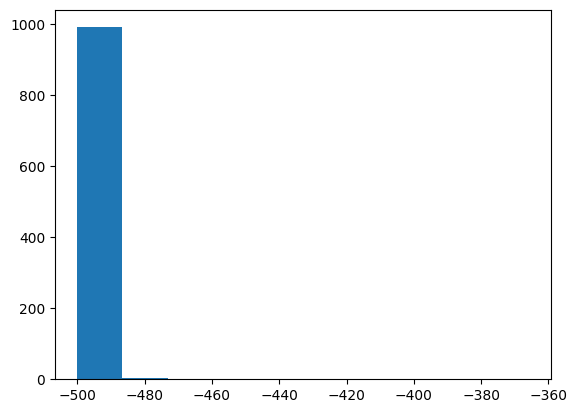

In [97]:
random_policy_rewards = gym_test_random_policy(env_config.env_name)
np.mean(random_policy_rewards)

Original VW
No matching hidden layer sizes found in the filename. Using the default of [16].
1 trajectories, split 2: Loaded a model with params of shape torch.Size([2500, 177]) from 1 files.


Testing: 100%|██████████| 300/300 [00:49<00:00,  6.10it/s]


Mean Reward: -90.58666666666667
No matching hidden layer sizes found in the filename. Using the default of [16].
1 trajectories, split 1: Loaded a model with params of shape torch.Size([2500, 177]) from 1 files.


Testing: 100%|██████████| 300/300 [00:48<00:00,  6.21it/s]


Mean Reward: -85.37333333333333
No matching hidden layer sizes found in the filename. Using the default of [16].
1 trajectories, split 4: Loaded a model with params of shape torch.Size([2500, 177]) from 1 files.


...

Mean Reward: -85.52
No matching hidden layer sizes found in the filename. Using the default of [16].
10 trajectories, split 2: Loaded a model with params of shape torch.Size([2500, 177]) from 1 files.


Testing: 100%|██████████| 300/300 [00:50<00:00,  5.93it/s]


Mean Reward: -90.00666666666666
No matching hidden layer sizes found in the filename. Using the default of [16].
10 trajectories, split 3: Loaded a model with params of shape torch.Size([2500, 177]) from 1 files.


Testing: 100%|██████████| 300/300 [00:47<00:00,  6.35it/s]


Mean Reward: -84.84


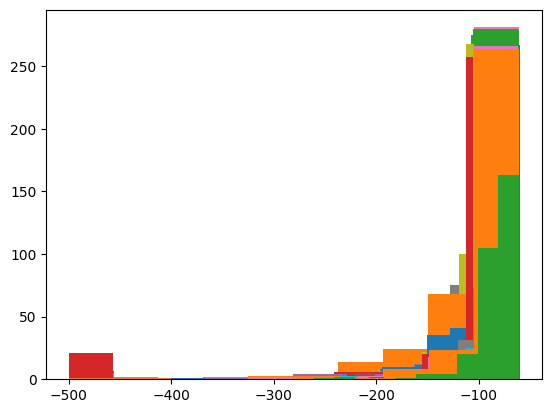

In [98]:
print("Original VW")
vw_test_rewards = get_test_rewards(vw_result_files)
print("Numpyro VW")
npy_test_rewards = get_test_rewards(npy_result_files)
print("Numpyro + Blackjax VW")
blj_test_rewards = get_test_rewards(blj_result_files)

In [99]:
split_mean_vw_rewards = {n_trajs: {split: np.mean(rewards) for split, rewards in split_dict.items()} for n_trajs, split_dict in vw_test_rewards.items()}
split_mean_npy_rewards = {n_trajs: {split: np.mean(rewards) for split, rewards in split_dict.items()} for n_trajs, split_dict in npy_test_rewards.items()}
split_mean_blj_rewards = {n_trajs: {split: np.mean(rewards) for split, rewards in split_dict.items()} for n_trajs, split_dict in blj_test_rewards.items()}

vw_means = np.array([np.mean(list(split_mean_vw_rewards[t].values())) for t in traj_nums])
vw_stds = np.array([np.std(list(vw_test_rewards[t].values())) for t in traj_nums])
vw_lb = vw_means - vw_stds
vw_ub = vw_means + vw_stds

npy_means = np.array([np.mean(list(split_mean_npy_rewards[t].values())) for t in traj_nums])
npy_stds = np.array([np.std(np.concatenate(list(npy_test_rewards[t].values()))) for t in traj_nums])
npy_lb = npy_means - npy_stds
npy_ub = npy_means + npy_stds

blj_means = np.array([np.mean(list(split_mean_blj_rewards[t].values())) for t in traj_nums])
blj_stds = np.array([np.std(np.concatenate(list(blj_test_rewards[t].values()))) for t in traj_nums])
blj_lb = blj_means - blj_stds
blj_ub = blj_means + blj_stds

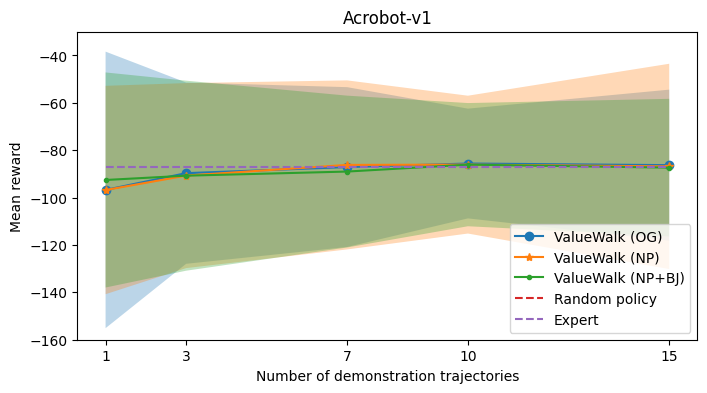

In [103]:
plt.figure(figsize=(8, 4))

expert_performance = -87

plt.plot(traj_nums, vw_means, label="ValueWalk (OG)", marker="o")
plt.plot(traj_nums, npy_means, label="ValueWalk (NP)", marker="*")
plt.plot(traj_nums, blj_means, label='ValueWalk (NP+BJ)', marker='.')

plt.plot(traj_nums, [np.mean(random_policy_rewards)]*len(traj_nums), label="Random policy", linestyle="--")
plt.plot(traj_nums, [expert_performance]*len(traj_nums), label="Expert", linestyle="--")

plt.fill_between(traj_nums, vw_lb, vw_ub, alpha=0.3)
plt.fill_between(traj_nums, npy_lb, npy_ub, alpha=0.3)
plt.fill_between(traj_nums, blj_lb, blj_ub, alpha=0.3)


plt.ylim(-160, -30)
plt.xticks(traj_nums)
plt.xlabel("Number of demonstration trajectories")
plt.ylabel("Mean reward")
plt.title(env_config.env_name)
plt.legend()

# Place legend in the bottom right corner
plt.legend(loc="lower right")
plt.show()

In [8]:
vw_time_dict = get_time_dict('original')
vw_time_means = np.array([np.mean(vw_time_dict[t]) for t in traj_nums])
vw_time_stds = np.array([np.std(vw_time_dict[t]) for t in traj_nums])
vw_time_lb = np.array([np.min(vw_time_dict[t]) for t in traj_nums])
vw_time_ub = np.array([np.max(vw_time_dict[t]) for t in traj_nums])

npy_time_dict = get_time_dict('numpyro__')
npy_time_means = np.array([np.mean(npy_time_dict[t]) for t in traj_nums])
npy_time_stds = np.array([np.std(npy_time_dict[t]) for t in traj_nums])
npy_time_lb = np.array([np.min(npy_time_dict[t]) for t in traj_nums])
npy_time_ub = np.array([np.max(npy_time_dict[t]) for t in traj_nums])

blj_time_dict = get_time_dict('numpyro_blackjax')
blj_time_means = np.array([np.mean(blj_time_dict[t]) for t in traj_nums])
blj_time_stds = np.array([np.std(blj_time_dict[t]) for t in traj_nums])
blj_time_lb = np.array([np.min(blj_time_dict[t]) for t in traj_nums])
blj_time_ub = np.array([np.max(blj_time_dict[t]) for t in traj_nums])

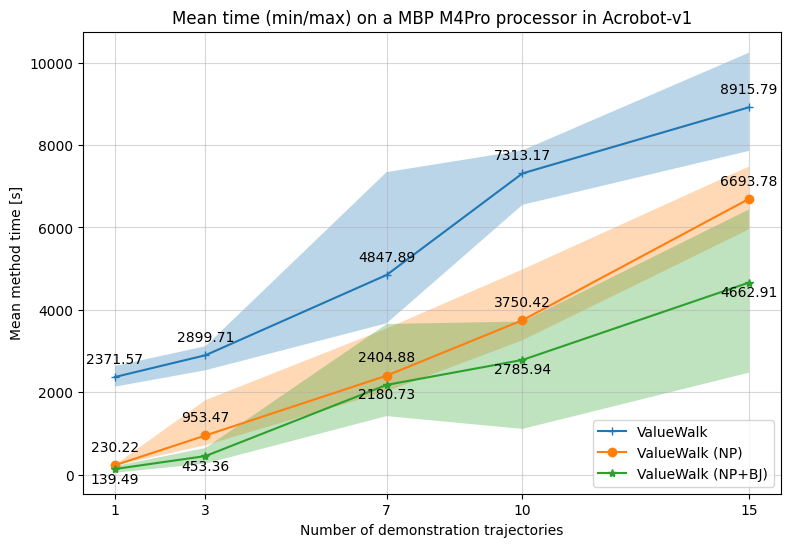

In [9]:
plt.figure(figsize=(9, 6))

plt.plot(traj_nums, vw_time_means, label='ValueWalk', marker='+')
plt.plot(traj_nums, npy_time_means, label="ValueWalk (NP)", marker="o", )
plt.plot(traj_nums, blj_time_means, label="ValueWalk (NP+BJ)", marker="*")

for x,y1, y2, y3 in zip(traj_nums,npy_time_means, blj_time_means, vw_time_means):

    label1 = "{:.2f}".format(y1)
    label2 = "{:.2f}".format(y2)
    label3 = "{:.2f}".format(y3)

    plt.annotate(label1, # this is the text
                 (x,y1), # these are the coordinates to position the label
                 textcoords="offset points", # how to position the text
                 xytext=(0,10), # distance from text to points (x,y)
                 ha='center') # horizontal alignment can be left, right or center
    
    plt.annotate(label2, # this is the text
                 (x,y2), # these are the coordinates to position the label
                 textcoords="offset points", # how to position the text
                 xytext=(0,-10), # distance from text to points (x,y)
                 ha='center') # horizontal alignment can be left, right or center
    
    plt.annotate(label3, # this is the text
                 (x,y3), # these are the coordinates to position the label
                 textcoords="offset points", # how to position the text
                 xytext=(0,10), # distance from text to points (x,y)
                 ha='center') # horizontal alignment can be left, right or center

plt.fill_between(traj_nums, vw_time_lb, vw_time_ub, alpha=0.3)
plt.fill_between(traj_nums, npy_time_lb, npy_time_ub, alpha=0.3)
plt.fill_between(traj_nums, blj_time_lb, blj_time_ub, alpha=0.3)

plt.xticks(traj_nums)
plt.xlabel("Number of demonstration trajectories")
plt.ylabel("Mean method time [s]")
plt.title(f'Mean time (min/max) on a MBP M4Pro processor in {env_config.env_name}')
plt.grid(alpha=0.5)
plt.legend()

# Place legend in the bottom right corner
plt.legend(loc="lower right")
plt.show()

In [17]:
# compute speedup factors

def safe_divide(arr1, arr2):
    min_len = min(len(arr1), len(arr2))
    return arr1[:min_len] / arr2[:min_len]

print("Numpyro VW")

average_npy_speedup = np.array([np.mean(safe_divide(np.array(vw_time_dict[t]), np.array(npy_time_dict[t]))) for t in traj_nums])
print(f"Average speedup factor (per no. demos): {average_npy_speedup}")
max_npy_speedup = np.array([np.max(safe_divide(np.array(vw_time_dict[t]), np.array(npy_time_dict[t]))) for t in traj_nums])
print(f"Max speedup: {max_npy_speedup}")
min_npy_speedup = np.array([np.min(safe_divide(np.array(vw_time_dict[t]), np.array(npy_time_dict[t]))) for t in traj_nums])
print(f"Min speedup: {min_npy_speedup}")

print("Blacjax VW")



average_blj_speedup = np.array([np.mean(safe_divide(np.array(vw_time_dict[t]), np.array(blj_time_dict[t]))) for t in traj_nums])
print(f"Average speedup factor (per no. demos): {average_blj_speedup}")
max_blj_speedup = np.array([np.max(safe_divide(np.array(vw_time_dict[t]), np.array(blj_time_dict[t]))) for t in traj_nums])
print(f"Max speedup: {max_blj_speedup}")
min_blj_speedup = np.array([np.min(safe_divide(np.array(vw_time_dict[t]), np.array(blj_time_dict[t]))) for t in traj_nums])
print(f"Min speedup: {min_blj_speedup}")



Numpyro VW
Average speedup factor (per no. demos): [10.30753151  3.5193749   2.15435414  2.01474016  1.33301818]
Max speedup: [11.46805309  4.20607118  3.57141862  2.37133821  1.50738527]
Min speedup: [9.002092   1.40031371 1.15860845 1.31449945 1.13158403]
Blacjax VW
Average speedup factor (per no. demos): [23.37399402  7.15597924  2.42582468  3.17627988  2.08920627]
Max speedup: [45.35230626 10.73591788  3.6928688   6.56984769  3.17218412]
Min speedup: [10.61883563  4.50358548  1.43445595  1.76137436  1.58033938]
